# SAR SR — Sanity Check Notebook

Run **once** after `scripts/preprocess.py --version 1` and `--version 2` complete.  
All 6 cells must pass before starting training.

Found 15 non-preview .tif files

Loading: ../data/raw/capella_geo\CAPELLA_C02_SP_GEO_HH_20201201165028_20201201165030.tif
Shape : (26137, 26505)
Dtype : float32
Min   : 0.000000
Max   : 65535.000000
% zero pixels : 69.92%
% NaN pixels  : 0.00%


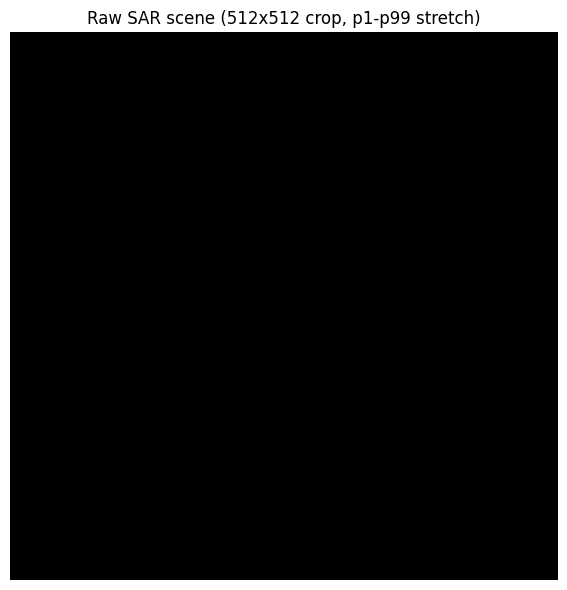

In [1]:
# Cell 1 — Check raw .tif files
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

tif_files = sorted(glob.glob('../data/raw/capella_geo/*.tif'))
tif_files = [f for f in tif_files if '_preview' not in f]
print(f'Found {len(tif_files)} non-preview .tif files')

sample_path = tif_files[0]
print(f'\nLoading: {sample_path}')

with rasterio.open(sample_path) as src:
    img = src.read(1).astype(np.float32)

pct_zero = np.mean(img == 0) * 100
pct_nan  = np.mean(np.isnan(img)) * 100

print(f'Shape : {img.shape}')
print(f'Dtype : {img.dtype}')
print(f'Min   : {img.min():.6f}')
print(f'Max   : {img.max():.6f}')
print(f'% zero pixels : {pct_zero:.2f}%')
print(f'% NaN pixels  : {pct_nan:.2f}%')

# Display a 512x512 crop so imshow is not too slow
crop = img[:512, :512]
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(crop, cmap='gray', vmin=np.percentile(crop, 1), vmax=np.percentile(crop, 99))
ax.set_title('Raw SAR scene (512x512 crop, p1-p99 stretch)')
ax.axis('off')
plt.tight_layout()
plt.show()

=== Phase 1 patch_000001 ===
HR shape : (256, 256)  (expected (256, 256))
LR shape : (64, 64)  (expected (64, 64))
HR  min=0.0000  max=1.0000  mean=0.2851
LR  min=0.0000  max=1.0000  mean=0.2854

All assertions passed.


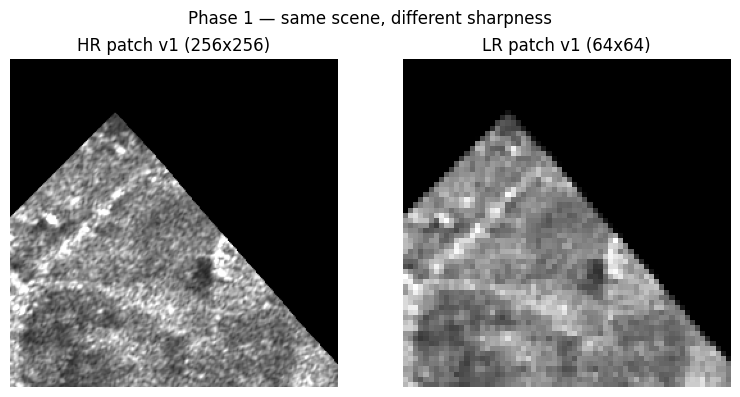

In [2]:
# Cell 2 — Check Phase 1 patches (no log transform)
import numpy as np
import matplotlib.pyplot as plt

hr_v1 = np.load('../data/patches_v1/hr/patch_000001.npy')
lr_v1 = np.load('../data/patches_v1/lr/patch_000001.npy')

print('=== Phase 1 patch_000001 ===')
print(f'HR shape : {hr_v1.shape}  (expected (256, 256))')
print(f'LR shape : {lr_v1.shape}  (expected (64, 64))')
print(f'HR  min={hr_v1.min():.4f}  max={hr_v1.max():.4f}  mean={hr_v1.mean():.4f}')
print(f'LR  min={lr_v1.min():.4f}  max={lr_v1.max():.4f}  mean={lr_v1.mean():.4f}')

assert hr_v1.shape == (256, 256), f'HR shape mismatch: {hr_v1.shape}'
assert lr_v1.shape == (64, 64),   f'LR shape mismatch: {lr_v1.shape}'
assert hr_v1.min() >= 0.0 and hr_v1.max() <= 1.0, 'HR values out of [0, 1]'
assert lr_v1.min() >= 0.0 and lr_v1.max() <= 1.0, 'LR values out of [0, 1]'
assert not np.isnan(hr_v1).any(), 'NaN in HR'
assert not np.isnan(lr_v1).any(), 'NaN in LR'
print('\nAll assertions passed.')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(hr_v1, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('HR patch v1 (256x256)')
axes[0].axis('off')
axes[1].imshow(lr_v1, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('LR patch v1 (64x64)')
axes[1].axis('off')
plt.suptitle('Phase 1 — same scene, different sharpness')
plt.tight_layout()
plt.show()

=== Phase 2 patch_000001 ===
HR shape : (256, 256)  (expected (256, 256))
LR shape : (64, 64)  (expected (64, 64))
HR  min=0.0000  max=1.0000  mean=0.4834
LR  min=0.0000  max=1.0000  mean=0.4839

All assertions passed.


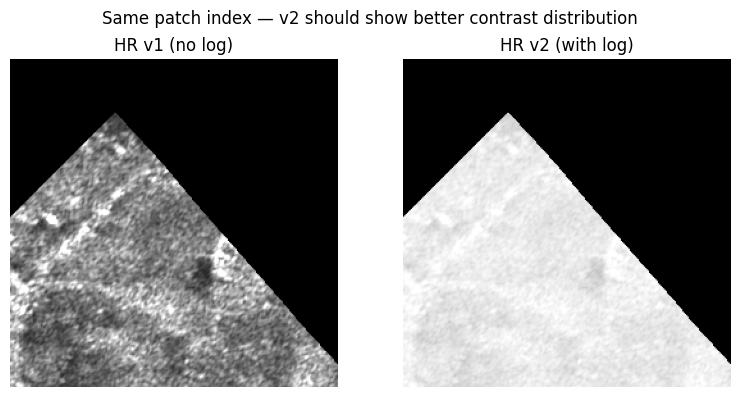

In [3]:
# Cell 3 — Check Phase 2 patches (with log transform)
import numpy as np
import matplotlib.pyplot as plt

hr_v2 = np.load('../data/patches_v2/hr/patch_000001.npy')
lr_v2 = np.load('../data/patches_v2/lr/patch_000001.npy')
hr_v1 = np.load('../data/patches_v1/hr/patch_000001.npy')  # for comparison

print('=== Phase 2 patch_000001 ===')
print(f'HR shape : {hr_v2.shape}  (expected (256, 256))')
print(f'LR shape : {lr_v2.shape}  (expected (64, 64))')
print(f'HR  min={hr_v2.min():.4f}  max={hr_v2.max():.4f}  mean={hr_v2.mean():.4f}')
print(f'LR  min={lr_v2.min():.4f}  max={lr_v2.max():.4f}  mean={lr_v2.mean():.4f}')

assert hr_v2.shape == (256, 256)
assert lr_v2.shape == (64, 64)
assert hr_v2.min() >= 0.0 and hr_v2.max() <= 1.0
assert not np.isnan(hr_v2).any()
print('\nAll assertions passed.')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(hr_v1, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('HR v1 (no log)')
axes[0].axis('off')
axes[1].imshow(hr_v2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('HR v2 (with log)')
axes[1].axis('off')
plt.suptitle('Same patch index — v2 should show better contrast distribution')
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — Check SARDataset class
import sys
sys.path.insert(0, '..')

from scripts.dataset import SARDataset

val_names_path = '../data/splits/val.txt'
with open(val_names_path) as f:
    val_names = [line.strip() for line in f if line.strip()][:5]

print(f'Using {len(val_names)} val patches for checks.')

# Without augmentation or speckle
ds = SARDataset(
    lr_dir='../data/patches_v1/lr',
    hr_dir='../data/patches_v1/hr',
    file_list=val_names,
    augment=False,
    speckle=False,
)
lr_t, hr_t = ds[0]
print(f'Without speckle: LR {tuple(lr_t.shape)}  HR {tuple(hr_t.shape)}')
assert tuple(lr_t.shape) == (1, 64, 64),   f'LR shape wrong: {lr_t.shape}'
assert tuple(hr_t.shape) == (1, 256, 256), f'HR shape wrong: {hr_t.shape}'

# With speckle
import numpy as np
ds_speckle = SARDataset(
    lr_dir='../data/patches_v1/lr',
    hr_dir='../data/patches_v1/hr',
    file_list=val_names,
    augment=False,
    speckle=True,
)
lr_sp, hr_sp = ds_speckle[0]
print(f'With speckle:    LR {tuple(lr_sp.shape)}  HR {tuple(hr_sp.shape)}')
assert tuple(lr_sp.shape) == (1, 64, 64)
# LR values should differ; HR stays the same
lr_diff = (lr_t - lr_sp).abs().max().item()
hr_diff = (hr_t - hr_sp).abs().max().item()
print(f'Max LR diff (speckle): {lr_diff:.6f}  (should be > 0)')
print(f'Max HR diff (speckle): {hr_diff:.6f}  (should be 0)')
assert lr_diff > 0, 'Speckle had no effect on LR'
assert hr_diff == 0, 'Speckle incorrectly modified HR'
print('\nAll dataset assertions passed.')

Using 5 val patches for checks.
Without speckle: LR (1, 64, 64)  HR (1, 256, 256)
With speckle:    LR (1, 64, 64)  HR (1, 256, 256)
Max LR diff (speckle): 0.779202  (should be > 0)
Max HR diff (speckle): 0.000000  (should be 0)

All dataset assertions passed.


In [5]:
# Cell 5 — Check model forward passes
import sys
sys.path.insert(0, '..')

import torch
from models.srcnn import SRCNN
from models.rcan import RCAN

dummy = torch.randn(1, 1, 64, 64)

srcnn = SRCNN()
srcnn.eval()
with torch.no_grad():
    out_srcnn = srcnn(dummy)

n_srcnn = sum(p.numel() for p in srcnn.parameters())
print(f'SRCNN output shape : {tuple(out_srcnn.shape)}  (expected (1, 1, 256, 256))')
print(f'SRCNN parameters   : {n_srcnn:,}  (expected ~57K)')
assert tuple(out_srcnn.shape) == (1, 1, 256, 256)
assert out_srcnn.min() >= 0.0 and out_srcnn.max() <= 1.0

rcan = RCAN()
rcan.eval()
with torch.no_grad():
    out_rcan = rcan(dummy)

n_rcan = sum(p.numel() for p in rcan.parameters())
print(f'\nRCAN output shape  : {tuple(out_rcan.shape)}  (expected (1, 1, 256, 256))')
print(f'RCAN parameters    : {n_rcan:,}  (expected ~16M)')
assert tuple(out_rcan.shape) == (1, 1, 256, 256)
assert out_rcan.min() >= 0.0 and out_rcan.max() <= 1.0

print('\nAll model assertions passed.')

SRCNN output shape : (1, 1, 256, 256)  (expected (1, 1, 256, 256))
SRCNN parameters   : 57,281  (expected ~57K)

RCAN output shape  : (1, 1, 256, 256)  (expected (1, 1, 256, 256))
RCAN parameters    : 15,885,473  (expected ~16M)

All model assertions passed.


In [6]:
# Cell 6 — Patch count summary

def count_lines(path):
    with open(path) as f:
        return sum(1 for line in f if line.strip())

n_train = count_lines('../data/splits/train.txt')
n_val   = count_lines('../data/splits/val.txt')
n_test  = count_lines('../data/splits/test.txt')
total   = n_train + n_val + n_test

import glob
n_scenes = len([f for f in glob.glob('../data/raw/capella_geo/*.tif') if '_preview' not in f])

print('=== Patch Count Summary ===')
print(f'Train : {n_train:>6}  ({n_train/total*100:.1f}%)')
print(f'Val   : {n_val:>6}  ({n_val/total*100:.1f}%)')
print(f'Test  : {n_test:>6}  ({n_test/total*100:.1f}%)')
print(f'Total : {total:>6}')
print(f'Scenes: {n_scenes}')
print(f'Avg patches per scene: {total/n_scenes:.1f}')

assert abs(n_train/total - 0.80) < 0.02, f'Train split is not ~80%: {n_train/total:.2%}'
assert abs(n_val/total   - 0.10) < 0.02, f'Val split is not ~10%: {n_val/total:.2%}'
assert abs(n_test/total  - 0.10) < 0.02, f'Test split is not ~10%: {n_test/total:.2%}'
print('\nSplit ratios are approximately 80/10/10. All checks passed.')

=== Patch Count Summary ===
Train :  38782  (80.0%)
Val   :   4847  (10.0%)
Test  :   4849  (10.0%)
Total :  48478
Scenes: 15
Avg patches per scene: 3231.9

Split ratios are approximately 80/10/10. All checks passed.
